# Gestion des imports

In [20]:
import matplotlib.image as mpimg
from matplotlib import pyplot as plt
import seaborn as sns
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import VGG16 
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import SGD, Adam

# Fonction de visualisation de la matrice de confusion

In [18]:
# Fonction pour afficher la matrice de confusion
def plot_confusion_matrix(y_true, y_pred):
    classe = [ "Jungle", "Plage", "Monuments", "Bus", "Dinosaures", "Elephants", "Fleurs", "Chevaux", "Montagne" , "Plats"]
    classe.sort()
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classe, yticklabels=classe)
    plt.xlabel('Prédictions')
    plt.ylabel('Vraies étiquettes')
    plt.title('Matrice de Confusion')
    plt.show()


# Chargement des données, normalisation des images, création des labels et séparation du jeu de données en 2

In [15]:
#charger liste des images
img_name = list()
for i in range(0,1000):
    img_name.append(str(i)+".jpg")
    
    
images = []
target_shape = (224, 224) 
for img in img_name:
    img = mpimg.imread('./Wang/' + img)
    img = cv2.resize(img, target_shape)
    images.append(img)

images = np.array(images)

# Normaliser les données en divisant par 255
images_normalized = images / 255.0
# Séparer les données en ensembles d'entraînement et de test
classe = [ "Jungle", "Plage", "Monuments", "Bus", "Dinosaures", "Elephants", "Fleurs", "Chevaux", "Montagne" , "Plats"]
label = []
for i in range(10):
    a = 0
    while a <100:
        label.append(classe[i])
        a+=1

# Convertir les étiquettes en encodage numérique
label_encoder = LabelEncoder()
label_encoded = label_encoder.fit_transform(label)
X_train, X_test, y_train, y_test = train_test_split(images_normalized, label_encoded, test_size=0.3, random_state=42)

# Chargement du modèle VGG19 couplé à une couche de dense de 512 neurones

In [16]:
vgg19 = keras.applications.vgg19
conv_model = vgg19.VGG19(weights='imagenet', include_top=False, input_shape=(224,224,3))

In [17]:
# Chargement du modèle pré-entraîné
base_model = conv_model
# Ajout d'une couche de Global Average Pooling (GAP)
x = base_model.output
x = GlobalAveragePooling2D()(x)

# Ajout d'une couche de classification personnalisée
x = Dense(512, activation='relu')(x)
predictions = Dense(10, activation='softmax')(x)  # 10 classes pour les étiquettes

# Création du modèle final
model = Model(inputs=base_model.input, outputs=predictions)

# Geler les couches du modèle pré-entraîné pour éviter la rétropropagation
for layer in base_model.layers:
    layer.trainable = False

# Compilation du modèle
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entraînement du modèle
model.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.2)

# Évaluation du modèle
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy}")

# Enregistrement du modèle
#model.save('image_classifier_model.h5')


Epoch 1/25
18/18 [==============================] - 228s 13s/step - loss: 1.9289 - accuracy: 0.4036 - val_loss: 1.3920 - val_accuracy: 0.6643
Epoch 2/25
18/18 [==============================] - 255s 14s/step - loss: 1.1452 - accuracy: 0.7589 - val_loss: 0.9433 - val_accuracy: 0.7643
Epoch 3/25
18/18 [==============================] - 212s 12s/step - loss: 0.7944 - accuracy: 0.7946 - val_loss: 0.7868 - val_accuracy: 0.7571
Epoch 4/25
18/18 [==============================] - 200s 11s/step - loss: 0.6208 - accuracy: 0.8554 - val_loss: 0.5740 - val_accuracy: 0.8714
Epoch 5/25
18/18 [==============================] - 203s 11s/step - loss: 0.4896 - accuracy: 0.8750 - val_loss: 0.5319 - val_accuracy: 0.8643
Epoch 6/25
18/18 [==============================] - 206s 12s/step - loss: 0.4465 - accuracy: 0.8875 - val_loss: 0.5027 - val_accuracy: 0.8500
Epoch 7/25
18/18 [==============================] - 200s 11s/step - loss: 0.3884 - accuracy: 0.9089 - val_loss: 0.4382 - val_accuracy: 0.8857
Epoch 

# Evaluation du modèle

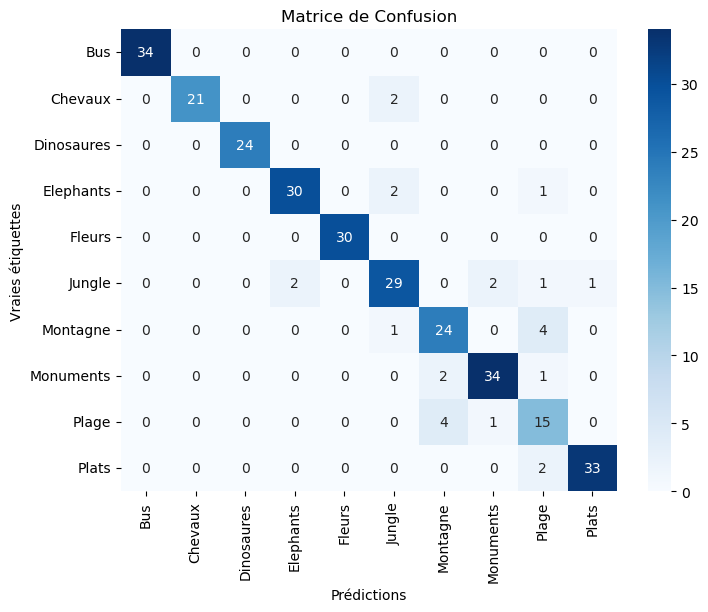

              precision    recall  f1-score   support

         Bus       1.00      1.00      1.00        34
     Chevaux       1.00      0.91      0.95        23
  Dinosaures       1.00      1.00      1.00        24
   Elephants       0.94      0.91      0.92        33
      Fleurs       1.00      1.00      1.00        30
      Jungle       0.85      0.83      0.84        35
    Montagne       0.80      0.83      0.81        29
   Monuments       0.92      0.92      0.92        37
       Plage       0.62      0.75      0.68        20
       Plats       0.97      0.94      0.96        35

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.92      0.91      0.92       300

0.915


In [21]:
y_predict = model.predict(X_test)
plot_confusion_matrix(y_test, np.argmax(y_predict, axis=1))
print(classification_report(label_encoder.inverse_transform(y_test), label_encoder.inverse_transform(np.argmax(y_predict, axis=1))))
print(round(f1_score(y_test, np.argmax(y_predict, axis=1), average='weighted'),3))